# The Range Estimators — a quantitative teardown \U0001F52C
### Parkinson · Garman-Klass · Rogers-Satchell · Yang-Zhang · QLIKE · Diebold-Mariano

![Signal: Real](https://img.shields.io/badge/Signal-Real-2ea44f?style=flat-square)
![Usefulness: Useful](https://img.shields.io/badge/Usefulness-Useful-2ea44f?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). The design
problem here is that **efficiency cannot be measured on real data**: there is no truth to
compare an estimator against without intraday prices. So the study splits in two — the
efficiency claim is tested in simulation where sigma is known, and the real tape is used for
the two questions it *can* answer: how much variance do the gap-blind estimators miss, and do
they forecast better once that level error is removed?

> ⚠️ **Not investment advice.** OHLC bars from Yahoo! Finance, pinned as-of the date in
> [`docs/results.md`](../docs/results.md); literature map in
> [`docs/references.md`](../docs/references.md).
>
> \U0001F4A1 **The `\U0001F4A1 In plain words` notes** translate each result back into intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../../.."))   # repo root (quantlab/ lives there)
sys.path.insert(0, os.path.abspath(".."))          # the study package
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 5.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25
import numpy as np, pandas as pd
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

In [2]:
from range_vol import data, strategy as st

bars = data.load_all()
spy = bars["SPY"]
print(f"as-of {data.AS_OF} | SPY {spy.index[0].date()} -> {spy.index[-1].date()} "
      f"({len(spy):,} bars, {data.bad_bar_count('SPY')} dropped as broken)")
print(f"overnight share of SPY's daily variance: {st.overnight_share(spy):.0%}")

as-of 2026-06-30 | SPY 1993-01-29 -> 2026-06-30 (8,411 bars, 0 dropped as broken)
overnight share of SPY's daily variance: 33%


## Verdict, up front

| Axis | Stamp | Why |
|---|---|---|
| **Signal** | Real | On simulated bars where the day's true sigma is known, Parkinson's estimator has **4.9x** the efficiency of close-to-close against the truth (Garman-Klass 6.8x, Rogers-Satchell 5.5x) — the textbook claim survives, in the textbook's own world. On the real tape that world does not exist: the overnight gap carries **33%** of SPY's daily variance and none of the three can see it, so they report **69%** of the close-to-close level. |
| **Usefulness** | Useful | Rescaled to remove that level error, the best range estimator (Yang-Zhang (2000)) beat close-to-close on QLIKE on **5 of 5** tapes with a pooled Diebold-Mariano *t* of **+3.73** — a real but modest improvement in forecasting the next month's realised variance (22.4% lower QLIKE on SPY). Yang-Zhang, the only gap-aware estimator, needs no rescaling and is the honest default. |

> \U0001F4A1 **In plain words.** The theorem is fine. The application is where the money is
> lost: three of the four range estimators are systematically low on any market that gaps, and
> the fix is either Yang-Zhang or an explicit rescaling.

## 1 · The claim, steelmanned

- **H₁ (efficiency).** Var(Parkinson) ≈ Var(close-to-close)/5 under the estimator's own
  assumptions — a driftless diffusion observed continuously, no gaps.
- **H₂ (bias).** On a market with an overnight gap of share *g*, the gap-blind estimators
  estimate (1 − *g*) of the daily variance, not all of it.
- **H₃ (usefulness).** After correcting the level, the range estimators forecast future
  realised variance better than close-to-close, and the improvement is statistically
  distinguishable by Diebold-Mariano.

## 2 · So what? — the quantitative stakes

A risk system that under-measures variance by 40% under-measures 99% VaR by the same 40%. A
vol-targeting overlay calibrated on Parkinson runs systematically hotter than its mandate.
Neither shows up as an error anywhere — the estimator is *precise*, so it never looks broken.

## 3 · How we'd know — the protocol

1. **Simulation with known sigma** (`data.synthetic_ohlc`), with the overnight share as a dial:
   the only setting where MSE-against-truth is computable.
2. **Level bias on the real tape**: each estimator's long-run mean against close-to-close,
   next to the measured overnight share of variance.
3. **A forecast race** on the real tape, raw and after a burn-in-only rescaling, scored with
   QLIKE (scale-free, robust to a noisy proxy — Patton 2011) and MSE.
4. **HAC Diebold-Mariano** on the loss differentials, because overlapping 21-day targets make
   them strongly autocorrelated.

## 4 · The teardown

### 4.1 Efficiency against a known sigma, as a function of the gap

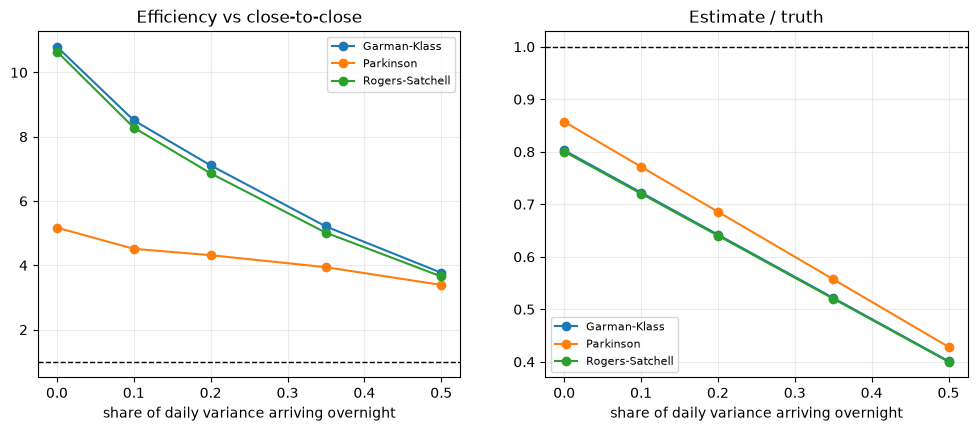

estimator,Garman-Klass,Parkinson,Rogers-Satchell
gap share,,,
0.0000,0.8030,0.8570,0.8000
0.1000,0.7220,0.7710,0.7200
0.2000,0.6420,0.6860,0.6400
0.3500,0.5220,0.5570,0.5200
0.5000,0.4010,0.4290,0.4000


In [3]:
rows = []
for g in (0.0, 0.1, 0.2, 0.35, 0.5):
    sim, tr = data.synthetic_ohlc(n_years=30, overnight_share=g, seed=965)
    e = st.efficiency_table(sim, tr["sigma"])
    for c in ("parkinson", "garman_klass", "rogers_satchell"):
        rows.append({"gap share": g, "estimator": st.ESTIMATOR_LABEL[c].split(" (")[0],
                     "efficiency": e.loc[c, "efficiency_vs_cc"],
                     "ratio to truth": e.loc[c, "mean_ratio_to_truth"]})
grid = pd.DataFrame(rows)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for name, sub in grid.groupby("estimator"):
    axes[0].plot(sub["gap share"], sub["efficiency"], marker="o", label=name)
    axes[1].plot(sub["gap share"], sub["ratio to truth"], marker="o", label=name)
axes[0].axhline(1, color="k", ls="--", lw=1); axes[0].set_title("Efficiency vs close-to-close")
axes[1].axhline(1, color="k", ls="--", lw=1); axes[1].set_title("Estimate / truth")
for a in axes:
    a.set_xlabel("share of daily variance arriving overnight"); a.legend(fontsize=8)
plt.show()
grid.pivot(index="gap share", columns="estimator", values="ratio to truth").round(3)

> \U0001F4A1 **In plain words.** As the gap grows, the range estimators keep *looking*
> excellent by their own standard — low variance of the estimate — while drifting further from
> the number you actually wanted.

### 4.2 The bias on five real tapes, against the measured gap share

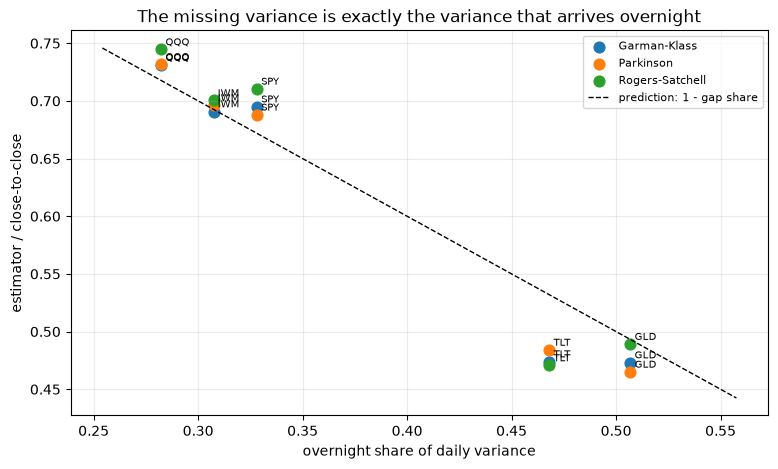

In [4]:
rows = []
for tk, b in bars.items():
    t = st.bias_table(b)
    for c in st.GAP_BLIND:
        rows.append({"ticker": tk, "estimator": st.ESTIMATOR_LABEL[c].split(" (")[0],
                     "ratio": t.loc[c, "ratio_to_cc"], "gap": st.overnight_share(b)})
d = pd.DataFrame(rows)
fig, ax = plt.subplots(figsize=(9, 5))
for name, sub in d.groupby("estimator"):
    ax.scatter(sub["gap"], sub["ratio"], s=60, label=name)
xs = np.linspace(d["gap"].min() * 0.9, d["gap"].max() * 1.1, 50)
ax.plot(xs, 1 - xs, color="k", ls="--", lw=1, label="prediction: 1 - gap share")
for _, r in d.iterrows():
    ax.annotate(r["ticker"], (r["gap"], r["ratio"]), fontsize=7,
                xytext=(3, 3), textcoords="offset points")
ax.set_xlabel("overnight share of daily variance"); ax.set_ylabel("estimator / close-to-close")
ax.set_title("The missing variance is exactly the variance that arrives overnight")
ax.legend(fontsize=8)
plt.show()

### 4.3 The raw forecast race — and why it is unfair

In [5]:
raw = st.forecast_race(spy, burn=504)
scaled = st.scaled_forecast_race(spy, burn=504)
cmp = pd.DataFrame({"QLIKE raw": raw["qlike"], "QLIKE rescaled": scaled["qlike"],
                    "scale applied": scaled["scale"]})
cmp.index = [st.ESTIMATOR_LABEL[c] for c in cmp.index]
print(cmp.round(4).to_string())
print("\nThe raw column mostly measures who has the right average level;")
print("the rescaled column measures who has the right shape.")

                        QLIKE raw  QLIKE rescaled  scale applied
Close-to-close             0.4759          0.4759         1.0000
Parkinson (1980)           0.6651          0.4068         1.5296
Garman-Klass (1980)        0.6603          0.3845         1.6851
Rogers-Satchell (1991)     0.6605          0.3897         1.6668
Yang-Zhang (2000)          0.4038          0.3693         1.1460

The raw column mostly measures who has the right average level;
the rescaled column measures who has the right shape.


### 4.4 Diebold-Mariano, with and without the HAC correction

In [6]:
est = st.rolling_variance(spy, 21)
target = st.realised_forward_var(spy, 21).shift(-1)
idx = est.index[504:]
train = est.iloc[:504].dropna()
rows = []
for c in st.ESTIMATORS:
    scale = train["close_close"].mean() / train[c].mean()
    pair = pd.concat([target.reindex(idx), est[c].reindex(idx) * scale], axis=1).dropna()
    ql_c = st.qlike(pair.iloc[:, 0], pair.iloc[:, 1])
    base_pair = pd.concat([target.reindex(idx), est["close_close"].reindex(idx)], axis=1).dropna()
    ql_b = st.qlike(base_pair.iloc[:, 0], base_pair.iloc[:, 1])
    rows.append({"estimator": st.ESTIMATOR_LABEL[c],
                 "DM (HAC)": st.diebold_mariano(ql_b, ql_c)["dm"],
                 "DM (no lags, wrong)": st.diebold_mariano(ql_b, ql_c, lags=0)["dm"]})
pd.DataFrame(rows).set_index("estimator").round(2)

,DM (HAC),"DM (no lags, wrong)"
estimator,,
Close-to-close,NaN,NaN
Parkinson (1980),2.8400,8.0300
Garman-Klass (1980),3.7400,10.4300
Rogers-Satchell (1991),3.3800,9.2600
Yang-Zhang (2000),5.3500,14.8200


> \U0001F4A1 **In plain words.** Ignore the overlap and every difference looks decisive. The
> HAC column is the one to read.

### 4.5 Does the answer survive the window choice?

In [7]:
rows = []
for w in (5, 10, 21, 63):
    t = st.scaled_forecast_race(spy, window=w, burn=504)
    best = t.drop(index=["close_close"])["qlike"].idxmin()
    rows.append({"window": w, "best estimator": st.ESTIMATOR_LABEL[best],
                 "QLIKE gain vs CC": 1 - t.loc[best, "qlike"] / t.loc["close_close", "qlike"],
                 "DM": t.loc[best, "dm_vs_cc"]})
pd.DataFrame(rows).set_index("window").round(4)

,best estimator,QLIKE gain vs CC,DM
window,,,
5,Yang-Zhang (2000),0.6312,7.1121
10,Yang-Zhang (2000),0.3709,6.6399
21,Yang-Zhang (2000),0.2241,5.3455
63,Yang-Zhang (2000),0.1090,2.5796


## 5 · The verdict

Efficiency: confirmed where it is defined. Bias: confirmed, and it is the size of the
overnight gap. Usefulness: positive, modest, and only after the level is corrected.

In [8]:
summary = []
for tk, b in bars.items():
    t = st.scaled_forecast_race(b, burn=504)
    best = t.drop(index=["close_close"])["qlike"].idxmin()
    summary.append({"ticker": tk, "overnight share": st.overnight_share(b),
                    "best estimator": st.ESTIMATOR_LABEL[best].split(" (")[0],
                    "QLIKE gain": 1 - t.loc[best, "qlike"] / t.loc["close_close", "qlike"],
                    "DM": t.loc[best, "dm_vs_cc"]})
s = pd.DataFrame(summary).set_index("ticker")
print(s.round(4).to_string())
print(f"\nbeats close-to-close on {(s['QLIKE gain'] > 0).sum()}/{len(s)} tapes; "
      f"mean DM {s['DM'].mean():+.2f}")

        overnight share best estimator  QLIKE gain     DM
ticker                                                   
SPY              0.3282     Yang-Zhang      0.2241 5.3455
QQQ              0.2824     Yang-Zhang      0.1130 2.5358
IWM              0.3073   Garman-Klass      0.2381 3.9613
GLD              0.5069     Yang-Zhang      0.2144 3.8510
TLT              0.4681     Yang-Zhang      0.1241 2.9447

beats close-to-close on 5/5 tapes; mean DM +3.73


## 6 · Could you use it?

Yes, with one instruction: **use Yang-Zhang, or rescale**. The estimator that is theoretically
best is the one that answers the question you asked — and "how much did this thing move today,
including while I was asleep" is a different question from "how much did it move during the
session".

## 7 · Going further

- **Realised variance from intraday bars** (Andersen & Bollerslev 1998) replaces the whole
  simulation section with a measurement.
- **Alizadeh, Brandt & Diebold (2002)**: the log-range is nearly Gaussian, which makes it a
  better *state variable* for a stochastic-volatility filter than a squared return — a natural
  fork of this study.
- **Microstructure-filtered extremes**: rebuild the high and low from NBBO-eligible prints.
- **Downstream cost**: run a vol-targeting overlay on each estimator and measure the tracking
  error against the mandate — the version of this question that has money attached.